# A Simple Autoencoder

In this notebook we'll build a simple autoencoder to compress the MNIST dataset. With autoencoders, we pass input data through an encoder that makes a compressed representation of the input. Then, this representation is passed through a decoder to reconstruct the input data. Generally the encoder and decoder will be built with neural networks, then trained on example data.

<img src='images/autoencoder_1.png' />

### Compressed Representation

A compressed representation can be great for saving and sharing any kind of data in a way that is more efficient than storing raw data. In practice, the compressed representation often holds key information about an input image and we can use it for denoising images or oher kinds of reconstruction and transformation!

<img src='images/denoising.png' width=60%/>

In this notebook, we'll be build a simple network architecture for the encoder and decoder. Let's get started by importing our libraries and getting the dataset.

In [1]:
# The MNIST datasets are hosted on yann.lecun.com that has moved under CloudFlare protection
# Run this script to enable the datasets download
# Reference: https://github.com/pytorch/vision/issues/1938
from six.moves import urllib
opener = urllib.request.build_opener()
opener.addheaders = [('User-agent', 'Mozilla/5.0')]
urllib.request.install_opener(opener)

In [2]:
import torch
import numpy as np
from torchvision import datasets
import torchvision.transforms as transforms

# convert data to torch.FloatTensor
transform = transforms.ToTensor()

# load the training and test datasets
train_data = datasets.MNIST(root='~/.pytorch/MNIST_data/', train=True,
                                   download=True, transform=transform)
test_data = datasets.MNIST(root='~/.pytorch/MNIST_data/', train=False,
                                  download=True, transform=transform)

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9.91M/9.91M [00:00<00:00, 36.5MB/s]


Extracting /home/student/.pytorch/MNIST_data/MNIST/raw/train-images-idx3-ubyte.gz to /home/student/.pytorch/MNIST_data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28.9k/28.9k [00:00<00:00, 1.04MB/s]

Extracting /home/student/.pytorch/MNIST_data/MNIST/raw/train-labels-idx1-ubyte.gz to /home/student/.pytorch/MNIST_data/MNIST/raw



Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1.65M/1.65M [00:00<00:00, 9.77MB/s]


Extracting /home/student/.pytorch/MNIST_data/MNIST/raw/t10k-images-idx3-ubyte.gz to /home/student/.pytorch/MNIST_data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4.54k/4.54k [00:00<00:00, 6.27MB/s]

Extracting /home/student/.pytorch/MNIST_data/MNIST/raw/t10k-labels-idx1-ubyte.gz to /home/student/.pytorch/MNIST_data/MNIST/raw



In [3]:
# Create training and test dataloaders

# number of subprocesses to use for data loading
num_workers = 0
# how many samples per batch to load
batch_size = 20

# prepare data loaders
train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, num_workers=num_workers)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size, num_workers=num_workers)

### Visualize the Data

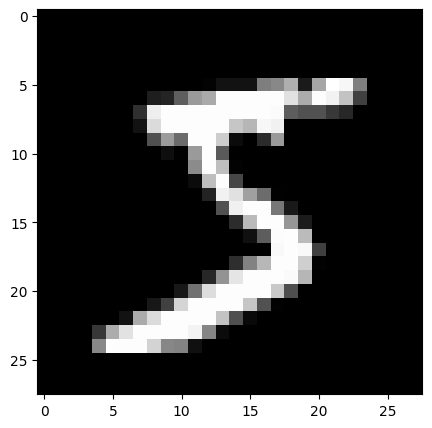

In [4]:
import matplotlib.pyplot as plt
%matplotlib inline
    
# obtain one batch of training images
dataiter = iter(train_loader)
images, labels = dataiter.__next__()
images = images.numpy()

# get one image from the batch
img = np.squeeze(images[0])

fig = plt.figure(figsize = (5,5)) 
ax = fig.add_subplot(111)
ax.imshow(img, cmap='gray')
plt.show()

---
## Linear Autoencoder

We'll train an autoencoder with these images by flattening them into 784 length vectors. The images from this dataset are already normalized such that the values are between 0 and 1. Let's start by building a simple autoencoder. The encoder and decoder will be made of **one linear layer**. The units that connect the encoder and decoder will be the _compressed representation_.

Since the images are normalized between 0 and 1, we need to use a **sigmoid activation on the output layer** to get values that match this input value range.

<img src='images/simple_autoencoder.png' width=50% />


We build the graph for the autoencoder in the cell below:
- The input images will be flattened into 784 length vectors. The targets are the same as the inputs. 
- The encoder and decoder will be made of two linear layers, each.
- The depth dimensions will change as follows: 784 inputs -> `encoding_dim` -> 784 outputs.
- All layers will have ReLU activations applied except for the final output layer, which has a sigmoid activation.

The compressed representation will be a vector with dimension `encoding_dim=32`.

In [5]:
import torch.nn as nn
import torch.nn.functional as F

# define the NN architecture
class Autoencoder(nn.Module):
    def __init__(self, encoding_dim):
        super(Autoencoder, self).__init__()
        ## encoder ##
        # linear layer (784 -> encoding_dim)
        self.fc1 = nn.Linear(28 * 28, encoding_dim)
        
        ## decoder ##
        # linear layer (encoding_dim -> input size)
        self.fc2 = nn.Linear(encoding_dim, 28*28)
        

    def forward(self, x):
        # add layer, with relu activation function
        x = F.relu(self.fc1(x))
        # output layer (sigmoid for scaling from 0 to 1)
        x = torch.sigmoid(self.fc2(x))
        return x

# initialize the NN
encoding_dim = 32
model = Autoencoder(encoding_dim)
print(model)

Autoencoder(
  (fc1): Linear(in_features=784, out_features=32, bias=True)
  (fc2): Linear(in_features=32, out_features=784, bias=True)
)


---
## Training

Here I'll write a bit of code to train the network. I'm not too interested in validation here, so I'll just monitor the training loss and the test loss afterwards. 

We are not concerned with labels in this case, just images, which we can get from the `train_loader`. Because we're comparing pixel values in input and output images, it will be best to use a loss that is meant for a regression task. Regression is all about comparing _quantities_ rather than probabilistic values. So, in this case, I'll use `MSELoss`. And compare output images and input images as follows:
```
loss = criterion(outputs, images)
```

Otherwise, this is pretty straightfoward training with PyTorch. We flatten our images, pass them into the autoencoder, and record the training loss as we go.

In [6]:
# specify loss function
criterion = nn.MSELoss()

# specify loss function
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [7]:
# check if CUDA is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [8]:
# number of epochs to train the model
n_epochs = 15

model.to(device)

for epoch in range(1, n_epochs + 1):
    model.train()
    train_loss = 0.0

    for images, _ in train_loader:
        # flatten images
        images = images.view(images.size(0), -1)
        # move to device
        images = images.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, images)   # mean over batch elements/pixels
        loss.backward()
        optimizer.step()

        train_loss += loss.item()           # accumulate batch means

    train_loss /= len(train_loader)         # mean of batch means
    print(f"Epoch: {epoch}\tTraining Loss: {train_loss:.6f}")

Epoch: 1	Training Loss: 0.031166
Epoch: 2	Training Loss: 0.014388
Epoch: 3	Training Loss: 0.012409
Epoch: 4	Training Loss: 0.012025
Epoch: 5	Training Loss: 0.011856
Epoch: 6	Training Loss: 0.011743
Epoch: 7	Training Loss: 0.011668
Epoch: 8	Training Loss: 0.011614
Epoch: 9	Training Loss: 0.011574
Epoch: 10	Training Loss: 0.011542
Epoch: 11	Training Loss: 0.011508
Epoch: 12	Training Loss: 0.011480
Epoch: 13	Training Loss: 0.011459
Epoch: 14	Training Loss: 0.011439
Epoch: 15	Training Loss: 0.011421


## Checking out the results

Below I've plotted some of the test images along with their reconstructions. For the most part these look pretty good except for some blurriness in some parts.

In [9]:
def plot_autoencoder_reconstructions(
    model,
    dataloader,
    device,
    batch_size=10,
    flatten_input=False
):
    """
    Plots original images and their reconstructions for an autoencoder.

    Parameters
    ----------
    model : torch.nn.Module
        Trained autoencoder model.
    dataloader : DataLoader
        DataLoader providing image batches.
    device : torch.device
        CPU or CUDA device.
    batch_size : int
        Number of images to display.
    flatten_input : bool
        True for MLP autoencoders, False for Conv autoencoders.
    """

    model.eval()

    # obtain one batch of test images
    images, _ = next(iter(dataloader))
    images = images.to(device)

    with torch.no_grad():
        if flatten_input:
            images_flat = images.view(images.size(0), -1)
            output = model(images_flat)
            output = output.view(images.size(0), 1, 28, 28)
        else:
            output = model(images)

    # move to CPU for plotting
    images_np = images.detach().cpu().numpy()
    output_np = output.detach().cpu().numpy()

    # plot
    fig, axes = plt.subplots(2, batch_size, figsize=(2.5 * batch_size, 4),
                             sharex=True, sharey=True)

    for imgs, row in zip([images_np, output_np], axes):
        for img, ax in zip(imgs[:batch_size], row):
            ax.imshow(np.squeeze(img), cmap="gray")
            ax.axis("off")

    plt.tight_layout()
    plt.show()

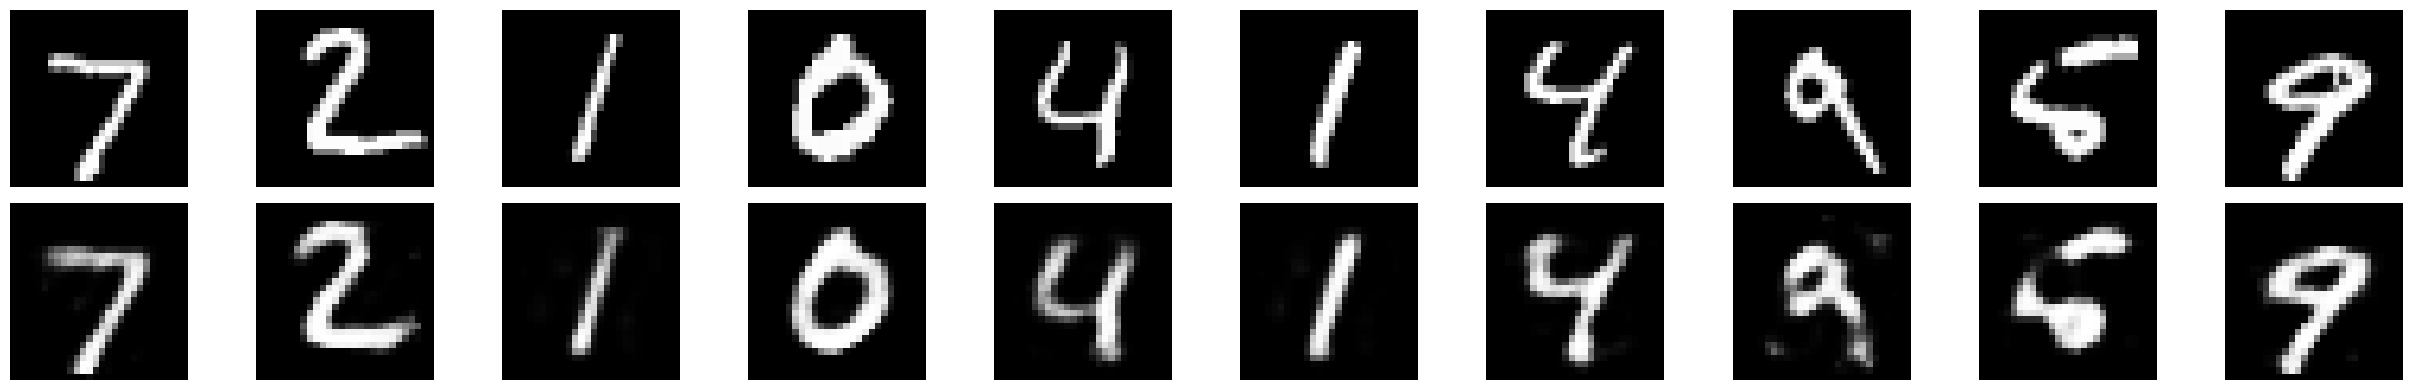

In [10]:
plot_autoencoder_reconstructions(
    model,
    test_loader,
    device,
    batch_size=10,
    flatten_input=True # we need to flatten input for MLP autoencoder
)

---
## Convolutional Autoencoder

We're dealing with images here, so we can (usually) get better performance using convolution layers. So, next we'll build a better autoencoder with convolutional layers.

The encoder portion will be made of convolutional and pooling layers and the decoder will be made of **transpose convolutional layers** that learn to "upsample" a compressed representation.



#### Encoder
The encoder part of the network will be a typical convolutional pyramid. Each convolutional layer will be followed by a max-pooling layer to reduce the dimensions of the layers. 

#### Decoder

The decoder though might be something new to you. The decoder needs to convert from a narrow representation to a wide, reconstructed image. For example, the representation could be a 7x7x4 max-pool layer. This is the output of the encoder, but also the input to the decoder. We want to get a 28x28x1 image out from the decoder so we need to work our way back up from the compressed representation. A schematic of the network is shown below.

<img src='images/conv_enc_1.png' width=640px>

Here our final encoder layer has size 7x7x4 = 196. The original images have size 28x28 = 784, so the encoded vector is 25% the size of the original image. These are just suggested sizes for each of the layers. Feel free to change the depths and sizes, in fact, you're encouraged to add additional layers to make this representation even smaller! Remember our goal here is to find a small representation of the input data.

### Transpose Convolutions, Decoder

This decoder uses **transposed convolutional** layers to increase the width and height of the input layers. They work almost exactly the same as convolutional layers, but in reverse. A stride in the input layer results in a larger stride in the transposed convolution layer. For example, if you have a 3x3 kernel, a 3x3 patch in the input layer will be reduced to one unit in a convolutional layer. Comparatively, one unit in the input layer will be expanded to a 3x3 path in a transposed convolution layer. PyTorch provides us with an easy way to create the layers, [`nn.ConvTranspose2d`](https://docs.pytorch.org/docs/stable/generated/torch.nn.ConvTranspose2d.html#torch.nn.ConvTranspose2d). 

It is important to note that transpose convolution layers can lead to artifacts in the final images, such as checkerboard patterns. This is due to overlap in the kernels which can be avoided by setting the stride and kernel size equal. In [this Distill article](http://distill.pub/2016/deconv-checkerboard/) from Augustus Odena, *et al*, the authors show that these checkerboard artifacts can be avoided by resizing the layers using nearest neighbor or bilinear interpolation (upsampling) followed by a convolutional layer. 


In [11]:
# define the NN architecture
class ConvAutoencoder(nn.Module):
    def __init__(self):
        super(ConvAutoencoder, self).__init__()
        ## encoder layers ##
        # conv layer (depth from 1 --> 16), 3x3 kernels
        self.conv1 = nn.Conv2d(1, 16, 3, padding=1)  
        # conv layer (depth from 16 --> 4), 3x3 kernels
        self.conv2 = nn.Conv2d(16, 4, 3, padding=1)
        # pooling layer to reduce x-y dims by two; kernel and stride of 2
        self.pool = nn.MaxPool2d(2, 2)
        
        ## decoder layers ##
        ## a kernel of 2 and a stride of 2 will increase the spatial dims by 2
        self.t_conv1 = nn.ConvTranspose2d(4, 16, 2, stride=2)
        self.t_conv2 = nn.ConvTranspose2d(16, 1, 2, stride=2)


    def forward(self, x):
        ## encode ##
        # add hidden layers with relu activation function
        # and maxpooling after
        x = F.relu(self.conv1(x))
        x = self.pool(x)
        # add second hidden layer
        x = F.relu(self.conv2(x))
        x = self.pool(x)  # compressed representation
        
        ## decode ##
        # add transpose conv layers, with relu activation function
        x = F.relu(self.t_conv1(x))
        # output layer (with sigmoid for scaling from 0 to 1)
        x = torch.sigmoid(self.t_conv2(x))
                
        return x

# initialize the NN
model = ConvAutoencoder()
print(model)

ConvAutoencoder(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (t_conv1): ConvTranspose2d(4, 16, kernel_size=(2, 2), stride=(2, 2))
  (t_conv2): ConvTranspose2d(16, 1, kernel_size=(2, 2), stride=(2, 2))
)


---
## Training

Here I'll write a bit of code to train the network. I'm not too interested in validation here, so I'll just monitor the training loss and the test loss afterwards. 

We are not concerned with labels in this case, just images, which we can get from the `train_loader`. Because we're comparing pixel values in input and output images, it will be best to use a loss that is meant for a regression task. Regression is all about comparing quantities rather than probabilistic values. So, in this case, I'll use `MSELoss`. And compare output images and input images as follows:
```
loss = criterion(outputs, images)
```

Otherwise, this is pretty straightfoward training with PyTorch. Since this is a convolutional autoencoder, our images _do not_ need to be flattened before being passed in an input to our model.

In [12]:
# specify loss function
criterion = nn.MSELoss()

# specify loss function
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [13]:
n_epochs = 15
model.to(device)

for epoch in range(1, n_epochs + 1):
    model.train()
    train_loss = 0.0

    for images, _ in train_loader:
        # no flattening needed for conv nets
        # move to device
        images = images.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, images)   # mean over batch elements/pixels
        loss.backward()
        optimizer.step()

        train_loss += loss.item()           # accumulate batch means

    train_loss /= len(train_loader)         # mean of batch means
    print(f"Epoch: {epoch}\tTraining Loss: {train_loss:.6f}")


Epoch: 1	Training Loss: 0.029283
Epoch: 2	Training Loss: 0.014253
Epoch: 3	Training Loss: 0.012986
Epoch: 4	Training Loss: 0.012323
Epoch: 5	Training Loss: 0.012030
Epoch: 6	Training Loss: 0.011853
Epoch: 7	Training Loss: 0.011728
Epoch: 8	Training Loss: 0.011635
Epoch: 9	Training Loss: 0.011558
Epoch: 10	Training Loss: 0.011501
Epoch: 11	Training Loss: 0.011454
Epoch: 12	Training Loss: 0.011414
Epoch: 13	Training Loss: 0.011377
Epoch: 14	Training Loss: 0.011342
Epoch: 15	Training Loss: 0.011313


## Checking out the results

Below I've plotted some of the test images along with their reconstructions. These look a little rough around the edges, likely due to the checkerboard effect we mentioned above that tends to happen with transpose layers.

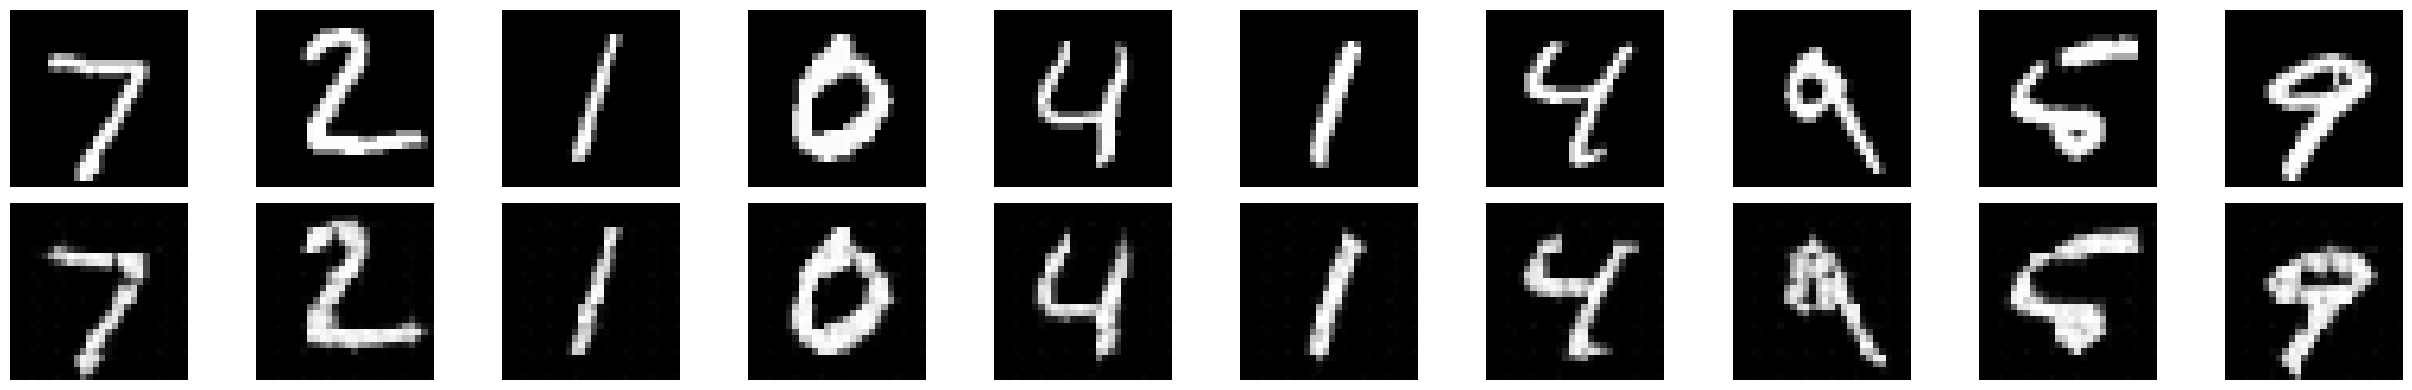

In [14]:
plot_autoencoder_reconstructions(
    model,
    test_loader,
    device,
    batch_size=10,
    flatten_input=False # no flattening for Conv autoencoder
)
